# Link to other Index

## Load final SLQI index dataset and HDR25_Statistical annex HDI dataset

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress

# Load final SLQI index dataset
slqi_df = pd.read_csv("../Dataset/final_SLQI_index_score.csv")

# Load HDI table
hdi_raw = pd.read_excel( "../Dataset/HDR25_Statistical_Annex_HDI_Table.xlsx", sheet_name="Table 1. HDI",header=5)

slqi_df.head()

,Country,Country Code,slqi_rank,slqi_score,economic_score,health_education_score,infrastructure_score,governance_score,environment_score
0,Monaco,MCO,1,0.882907,0.929004,1.000000,1.000000,0.879639,0.387073
1,Finland,FIN,2,0.878255,0.628200,0.882677,0.997947,0.907696,0.767288
2,Sweden,SWE,3,0.869694,0.630972,0.876169,0.994087,0.863665,0.773135
3,Liechtenstein,LIE,4,0.866357,0.834928,0.835668,0.999814,0.932930,0.615199
4,Norway,NOR,5,0.847282,0.707388,0.811397,0.992738,0.909410,0.659276


## Clean HDI data

In [36]:
# Rename useful columns
hdi_df = hdi_raw.rename(columns={"HDI rank": "hdi_rank","Value": "hdi_2023"})

# Convert to numeric
hdi_df["hdi_rank"] = pd.to_numeric(hdi_df["hdi_rank"], errors="coerce")
hdi_df["hdi_2023"] = pd.to_numeric(hdi_df["hdi_2023"], errors="coerce")

# Keep only country-level rows
hdi_df = hdi_df[ hdi_df["Country"].notna() & hdi_df["hdi_rank"].notna() & hdi_df["hdi_2023"].notna() ].copy()

# Keep only needed columns
hdi_df = hdi_df[["Country", "hdi_rank","hdi_2023"]]

hdi_df.head()

,Country,hdi_rank,hdi_2023
2,Iceland,1.0,0.972
3,Norway,2.0,0.970
4,Switzerland,2.0,0.970
5,Denmark,4.0,0.962
6,Germany,5.0,0.959


## Mapping country's name between two dataset

In [37]:
country_name_mapping = {
    "Korea, Rep.": "Korea (Republic of)",
    "Hong Kong SAR, China": "Hong Kong, China (SAR)",
    "Macao SAR, China": "Macao, China (SAR)",
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "St. Lucia": "Saint Lucia",
    "Bahamas, The": "Bahamas",
    "Gambia, The": "Gambia",
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran (Islamic Republic of)",
    "Venezuela, RB": "Venezuela (Bolivarian Republic of)",
    "Yemen, Rep.": "Yemen",
    "Congo, Dem. Rep.": "Congo (Democratic Republic of the)",
    "Congo, Rep.": "Congo",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Lao PDR": "Lao People's Democratic Republic",
    "Slovak Republic": "Slovakia",
   "Syrian Arab Republic": "Syrian Arab Republic",
    "Turkiye": "Türkiye",
    "Russian Federation": "Russian Federation",
    "Vietnam": "Viet Nam",
    "Brunei Darussalam": "Brunei Darussalam",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Micronesia, Fed. Sts.": "Micronesia (Federated States of)",
    "Virgin Islands (U.S.)": "United States Virgin Islands",
    "Moldova": "Moldova (Republic of)",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Eswatini": "Eswatini (Kingdom of)",
    "Tanzania": "Tanzania (United Republic of)",
    "Somalia, Fed. Rep.": "Somalia",
    "West Bank and Gaza": "Palestine, State of",

}

In [38]:
slqi_df["Country_for_merge"] = slqi_df["Country"].replace(country_name_mapping)
hdi_df["Country_for_merge"] = hdi_df["Country"]

## Merge SLQI and HDI

In [39]:
slqi_hdi_df = pd.merge(slqi_df, hdi_df, on="Country_for_merge", how="inner",suffixes=("_slqi", "_hdi"))
print("Matched countries:", slqi_hdi_df.shape[0])

Matched countries: 193


In [ ]:
unmatched_slqi = slqi_df[ ~slqi_df["Country_for_merge"].isin(slqi_hdi_df["Country_for_merge"])][["Country", "Country_for_merge"]]
unmatched_slqi.head(20)

,Country,Country_for_merge
0,Monaco,Monaco
28,"Macao SAR, China","Macao, China (SAR)"
39,Bermuda,Bermuda
40,Virgin Islands (U.S.),United States Virgin Islands
41,French Polynesia,French Polynesia
46,Guam,Guam
47,Aruba,Aruba
51,Puerto Rico (US),Puerto Rico (US)
52,Cayman Islands,Cayman Islands
54,New Caledonia,New Caledonia


In [41]:
r, p_value = pearsonr(
    slqi_hdi_df["slqi_score"],
    slqi_hdi_df["hdi_2023"]
)

print("Pearson correlation coefficient:", r)
print("P-value:", p_value)

Pearson correlation coefficient: 0.9371588345656832
P-value: 2.7882648961620655e-89


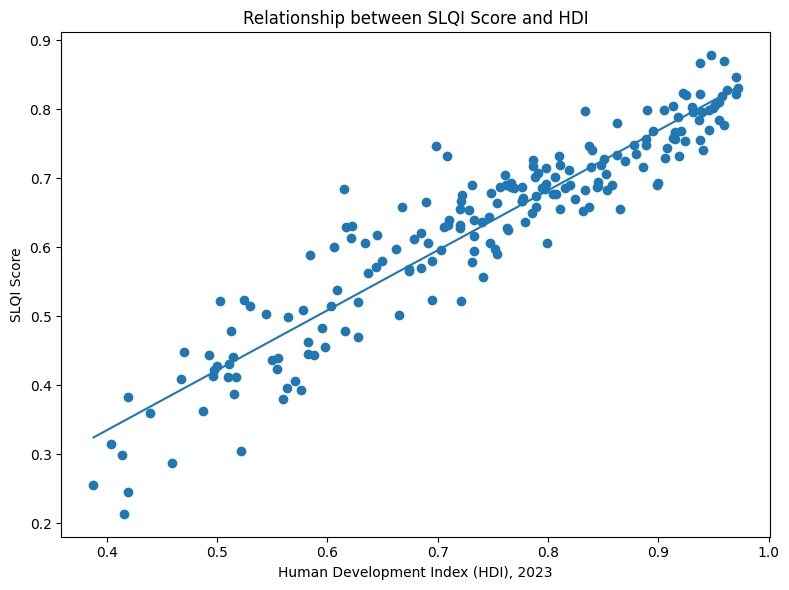

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    slqi_hdi_df["hdi_2023"],
    slqi_hdi_df["slqi_score"]
)

# Trend line
m, b = np.polyfit(
    slqi_hdi_df["hdi_2023"],
    slqi_hdi_df["slqi_score"],
    1
)

x_values = np.linspace(
    slqi_hdi_df["hdi_2023"].min(),
    slqi_hdi_df["hdi_2023"].max(),
    100
)

y_values = m * x_values + b

plt.plot(x_values, y_values)

plt.xlabel("Human Development Index (HDI), 2023")
plt.ylabel("SLQI Score")
plt.title("Relationship between SLQI Score and HDI")

plt.tight_layout()
plt.show()

In [47]:
regression_result = linregress(
    slqi_hdi_df["hdi_2023"],
    slqi_hdi_df["slqi_score"]
)

print("Slope:", regression_result.slope)
print("Intercept:", regression_result.intercept)
print("R-squared:", regression_result.rvalue ** 2)
print("P-value:", regression_result.pvalue)

Slope: 0.869721292523743
Intercept: -0.013220539440527368
R-squared: 0.8782666812045091
P-value: 2.7882648961630582e-89


After matching countries between the SLQI dataset and the HDI dataset, Pearson correlation was calculated between SLQI score and HDI value. The result showed a strong positive correlation between the two indicators.

In [ ]:
slqi_hdi_df.to_csv( "../Dataset/slqi_hdi_linked_dataset.csv",index=False)